In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

C:\Users\nico_\AppData\Local\Temp\ipykernel_22932\1729889758.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
# Embedding
embd=OpenAIEmbeddings()

# Docs to Index
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/"
]

# Load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=500,chunk_overlap=50) # 500 tokens

doc_splits = text_splitter.split_documents(docs_list)

# Vector Store
vectorstore=FAISS.from_documents(documents=doc_splits,embedding=embd)

retriever = vectorstore.as_retriever()

In [5]:
### Router

from typing import Literal

from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

from pydantic import BaseModel, Field

class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""

    datasource: Literal["vectorstore","web_search"] = Field(description="Given a user question choose to route it to web search or a vectorstore.")

# LLM with function call
llm = ChatOpenAI(model="gpt-4o",temperature=0)
structured_llm_router = llm.with_structured_output(RouteQuery)

# Prompt
system = """You are an expert at routing a user question to a vectorstore or web search.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use web-search."""

route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human","{question}")
    ]
)

question_router = route_prompt | structured_llm_router

In [6]:
print(question_router.invoke({"question":"Who won the football world cup in 1998?"}))

datasource='web_search'


In [7]:
print(question_router.invoke({"question": "What are the types of agent memory?"}))

datasource='vectorstore'


In [8]:
# Retrieval grader

class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

# LLM with function call
llm = ChatOpenAI(model="gpt-4o",temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}")
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

question = "Agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question":question,"document":doc_txt}))

binary_score='yes'


In [11]:
# Generate

from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are an assistant for question-answering tasks.
        Use the retrieved context to answer the question.
        If the answer is not in the context, say that you do not know.
        Keep the answer concise.
        
        Context:
        {context}
        """
    ),
    ("human",
     "question: {question}")
])

llm = ChatOpenAI(model="gpt-4o",temperature=0)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = prompt | llm | StrOutputParser()

generation = rag_chain.invoke({
    "context":format_docs(docs),
    "question":question
})

print(generation)

Agent memory refers to the mechanisms used by autonomous agents, often powered by large language models (LLMs), to store and retrieve information about past experiences. This memory can be structured in various ways, such as:

1. **Memory Stream**: A long-term memory module that records a comprehensive list of an agent's experiences in natural language. Each element in this stream is an observation or event directly provided by the agent, and inter-agent communication can trigger new natural language statements.

2. **Self-Reflection**: This aspect allows agents to iteratively improve by refining past action decisions and correcting previous mistakes. It is crucial for real-world tasks where trial and error are inevitable.

3. **External Memory**: This can be an external vector store that the agent can access at query time, allowing for fast retrieval of information. It helps alleviate the restriction of finite attention span by saving embedding representations of information into a da

In [12]:
print(prompt.input_variables)

['context', 'question']


In [13]:
### Hallucination Grader

class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(description="Answer is grounded in the facts, 'yes' or 'no'")

# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""

hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human", "Set of facts: \n\n {document} \n\n LLM generation: {generation}")
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"document": format_docs(docs),"generation": generation})

GradeHallucinations(binary_score='no')

In [14]:
### Answer Grader


# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(binary_score='yes')

In [15]:
### Question Re-writer

# LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Prompt
system = """You are question re-writer that converts an input question to a better version that is optimized \n 
     for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Here is the in initial question: \n\n {question} \n Formulate an improved question.")
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'What are the key concepts and functionalities of agent memory in artificial intelligence?'

In [16]:
### Search

from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(max_results=3) # 3 premiers résultats

In [17]:
from typing import List

from typing_extensions import TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[str]

In [18]:
from langchain_core.documents import Document

def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """

    print("---RETRIEVE---")
    question = state["question"]

    documents = retriever.invoke(question)
    return {"documents":documents, "question":question}

def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """

    print("GENERATE")
    question = state["question"]
    documents = state["documents"]

    generation = rag_chain.invoke({"context":format_docs(documents),"question":question})
    return {"documents":documents,"question":question,"generation":generation}

def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []

    for d in documents:
        score = retrieval_grader.invoke({"question":question,"document":d.page_content})
        grade = score.binary_score
        
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}

def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}

def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]

    docs = web_search_tool.invoke({"query": question})

    results = docs["results"]

    web_results = "\n".join([d["content"] for d in results]) # les résultats du moteur de recherche sont des dictionnaires avec une clé "content"
                                                          # les objets Document de LangChain utilisent un attribut page_content
    web_results = Document(page_content=web_results) # convertit les résultats du moteur de recherche (des dictionnaires) en un Document, afin 
                                                     # que le reste du pipeline manipule toujours le même type d'objet (Document).

    return {"documents": [web_results], "question": question}

# Edges

def route_question(state):
    """
    Route question to web search or RAG.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """

    print("---ROUTE QUESTION---")
    question = state["question"]
    source = question_router.invoke({"question":question})
    
    if source.datasource == "web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    elif source.datasource == "vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"
    
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    question = state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"
    
def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke({"document": format_docs(documents),"generation": generation})

    grade = score.binary_score

    if grade == "yes":
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    
    else:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

In [19]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("web_search", web_search)  # web search
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query

# Build graph
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)
workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "retrieve")
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

# Compile
app = workflow.compile()

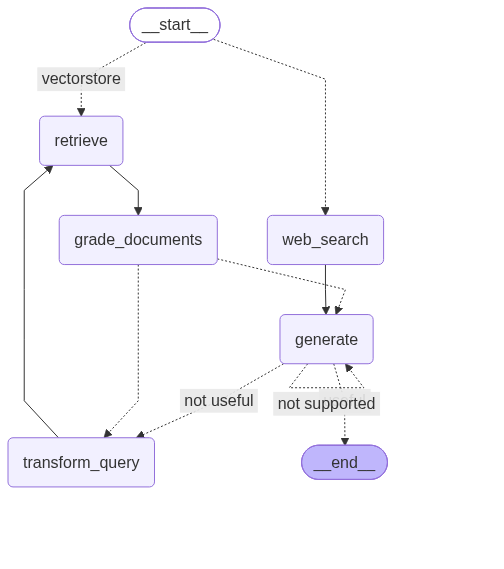

In [20]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [21]:
app.invoke({"question":"What is machine learning"})

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
GENERATE
---CHECK HALLUCINATIONS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What is machine learning',
 'generation': 'Machine learning is a subfield of artificial intelligence that uses algorithms and data to create models capable of performing tasks without explicit human intervention. It involves training algorithms on data sets to enable them to learn patterns and make predictions or classifications on new data. Machine learning can be used for tasks such as categorizing images, analyzing data, or predicting outcomes. It is a branch of AI that focuses on enabling systems to learn and improve over time, similar to human learning.',
 'documents': [Document(metadata={}, page_content='# What is Machine Learning? Machine learning is a type of artificial intelligence that performs data analysis tasks without explicit instructions. Machine learning technology can process large quantities of historical data, identify patterns, and predict new relationships between previously unknown data. For example, a financial organization could train a machine le

In [22]:
app.invoke({"question":"What is agent memory"})

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
GENERATE
---CHECK HALLUCINATIONS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What is agent memory',
 'generation': 'Agent memory refers to the mechanisms used by an autonomous agent, often powered by a large language model (LLM), to acquire, store, retain, and later retrieve information. It is categorized into:\n\n1. **Short-term memory**: Utilizes in-context learning, which is limited by the finite context window length of the model.\n2. **Long-term memory**: Involves an external vector store that the agent can access via fast retrieval methods like Maximum Inner Product Search (MIPS) to retain and recall information over extended periods.',
 'documents': [Document(id='826a53e3-82fd-4fd4-9b80-82707e18b558', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The po